# Notebook Overview

**Purpose:**
This notebook performs an exploratory analysis of sentiment-augmented stock time series data, with Apple (AAPL) as the primary example and a cross-asset comparison across all available tickers. It applies a consistent thesis plotting style, visualises the price series and dataset splits, and quantifies news coverage and FinBERT-derived sentiment characteristics at both the single-asset and multi-asset level.

**Inputs:**
- Sentiment-augmented time series CSV for AAPL: `../data/ts_with_sentiment/AAPL_ts_with_sentiment.csv` (expects `Date`, `Close`, `pos_mean`, `neut_mean`, `neg_mean`, `news_count`).
- Directory of sentiment-augmented CSVs for all tickers: `../data/ts_with_sentiment/*_ts_with_sentiment.csv`.
- Matplotlib style settings defined in `set_hhn_plot_style()`.

**Outputs:**
- A set of publication-ready figures, including:
  - AAPL closing-price time series and the train/validation/test split visualisation.
  - Distribution of daily news counts and mean sentiment composition for AAPL.
  - Rolling sentiment trends (e.g., 30-day means) and scatter plots linking news intensity to sentiment and absolute returns.
  - Cross-asset bar charts comparing average news coverage and dominant-sentiment distributions.
- Printed descriptive statistics for AAPL, including total news volume, average news per day, zero-news days, and dominant sentiment shares (unweighted and weighted by news count).
- Summary tables (`coverage_df`, `sentiment_df`) for multi-asset news coverage and dominant sentiment structure.

**Process Summary:**
The notebook first defines and activates a consistent Matplotlib style for thesis figures. It then loads the AAPL sentiment-augmented dataset, visua


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

# === HHN-Thesis Plot Style ===
def set_hhn_plot_style():
    plt.style.use('default')
    mpl.rcParams.update({
        # Schrift & Text
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
        'font.size': 11,
        'axes.titlesize': 12,
        'axes.labelsize': 11,
        'legend.fontsize': 10,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,

        # Linien
        'lines.linewidth': 1.4,
        'lines.markersize': 4,

        # Farben
        'axes.prop_cycle': mpl.cycler(color=[
            '#003366',  # HHN-Blau (primär)
            '#999999',  # neutral Grau
            '#0072B2',  # heller Blauton für Vergleiche
            '#CC0000',  # Akzentrot für negative Werte / RMSE etc.
            '#56B4E9',  # hellblau (z. B. für Sentiment)
        ]),

        # Achsen & Gitter
        'axes.edgecolor': '#333333',
        'axes.linewidth': 0.8,
        'axes.grid': True,
        'grid.color': '#cccccc',
        'grid.linestyle': '--',
        'grid.linewidth': 0.6,

        # Hintergrund
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',

        # Legende
        'legend.frameon': False,
        'legend.loc': 'best',

        # Savefig
        'savefig.dpi': 300,
        'savefig.bbox': 'tight'
    })

set_hhn_plot_style()


In [4]:
# Plot-Style setzen
set_hhn_plot_style()

# Daten laden
df = pd.read_csv(
    "../../data/ts_with_sentiment/AAPL_ts_with_sentiment.csv",
    parse_dates=["Date"]
)

df = df.sort_values("Date").reset_index(drop=True)


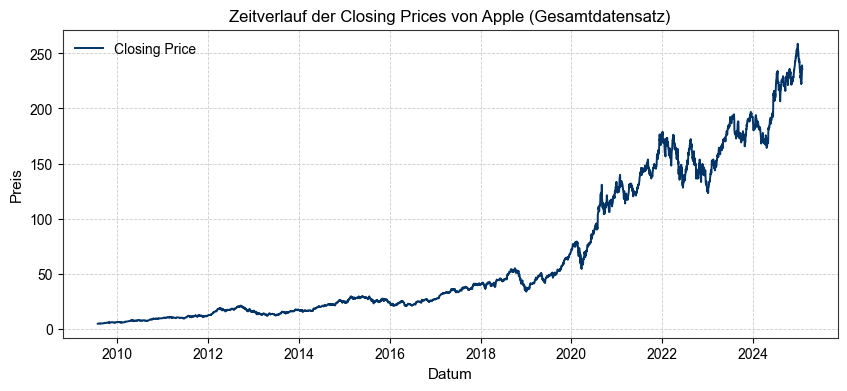

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(df["Date"], df["Close"], label="Closing Price")
plt.xlabel("Datum")
plt.ylabel("Preis")
plt.title("Zeitverlauf der Closing Prices von Apple (Gesamtdatensatz)")
plt.legend()
plt.show()


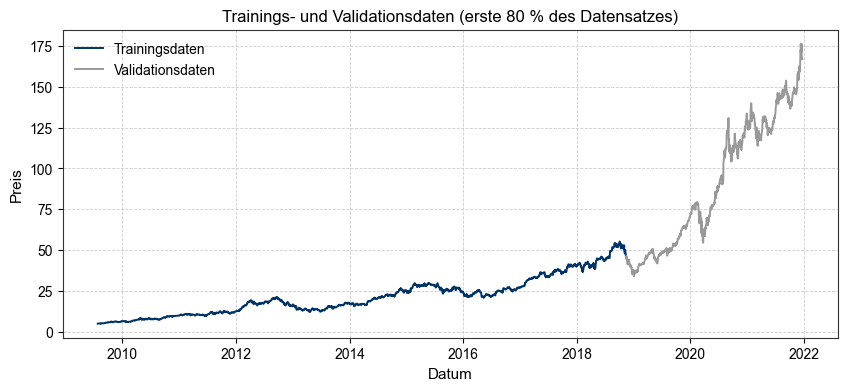

In [6]:
n_total = len(df)

# Indizes berechnen
train_end = int(0.60 * n_total)
val_end   = int(0.80 * n_total)

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]

plt.figure(figsize=(10, 4))
plt.plot(df_train["Date"], df_train["Close"], label="Trainingsdaten")
plt.plot(df_val["Date"], df_val["Close"], label="Validationsdaten")
plt.xlabel("Datum")
plt.ylabel("Preis")
plt.title("Trainings- und Validationsdaten (erste 80 % des Datensatzes)")
plt.legend()
plt.show()


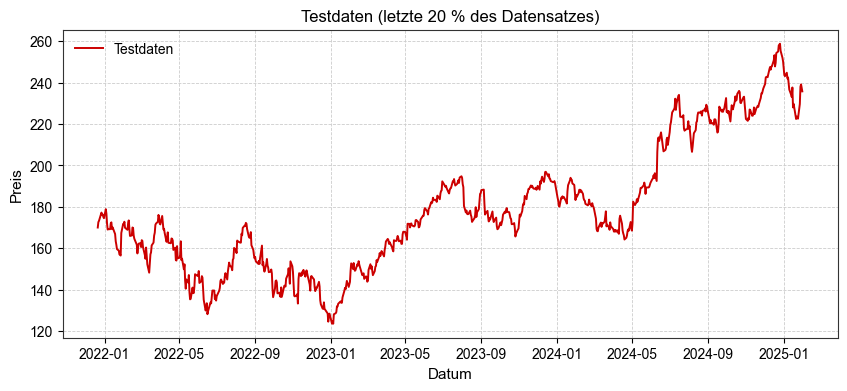

In [7]:
df_test = df.iloc[val_end:]

plt.figure(figsize=(10, 4))
plt.plot(df_test["Date"], df_test["Close"], label="Testdaten", color="#CC0000")
plt.xlabel("Datum")
plt.ylabel("Preis")
plt.title("Testdaten (letzte 20 % des Datensatzes)")
plt.legend()
plt.show()


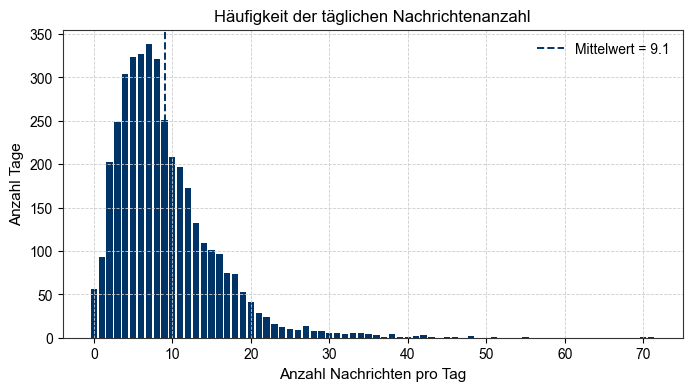

In [8]:
counts = df["news_count"].value_counts().sort_index()
mean_news = df["news_count"].mean()

plt.figure(figsize=(8, 4))
plt.bar(counts.index, counts.values)
plt.axvline(
    mean_news,
    linestyle="--",
    label=f"Mittelwert = {mean_news:.1f}"
)
plt.xlabel("Anzahl Nachrichten pro Tag")
plt.ylabel("Anzahl Tage")
plt.title("Häufigkeit der täglichen Nachrichtenanzahl")
plt.legend()
plt.show()


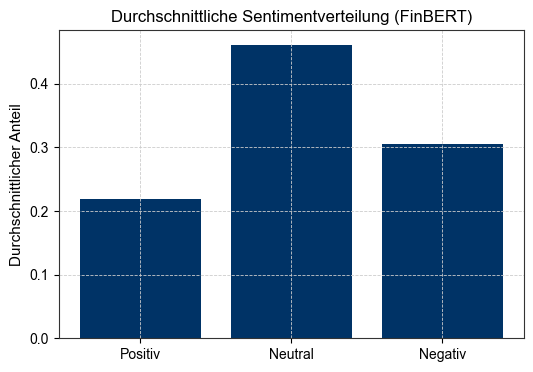

In [9]:
sentiment_means = df[["pos_mean", "neut_mean", "neg_mean"]].mean()

plt.figure(figsize=(6, 4))
plt.bar(
    ["Positiv", "Neutral", "Negativ"],
    sentiment_means.values
)
plt.ylabel("Durchschnittlicher Anteil")
plt.title("Durchschnittliche Sentimentverteilung (FinBERT)")
plt.show()


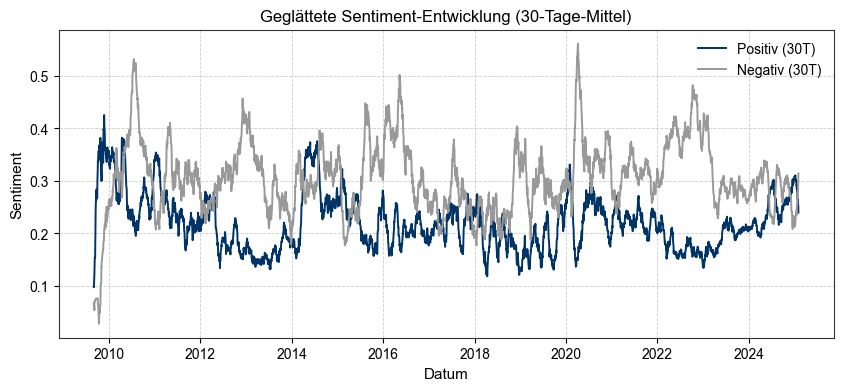

In [10]:
window = 30  # 30 Tage

plt.figure(figsize=(10, 4))
plt.plot(df["Date"], df["pos_mean"].rolling(window).mean(), label="Positiv (30T)")
plt.plot(df["Date"], df["neg_mean"].rolling(window).mean(), label="Negativ (30T)")
plt.xlabel("Datum")
plt.ylabel("Sentiment")
plt.title("Geglättete Sentiment-Entwicklung (30-Tage-Mittel)")
plt.legend()
plt.show()


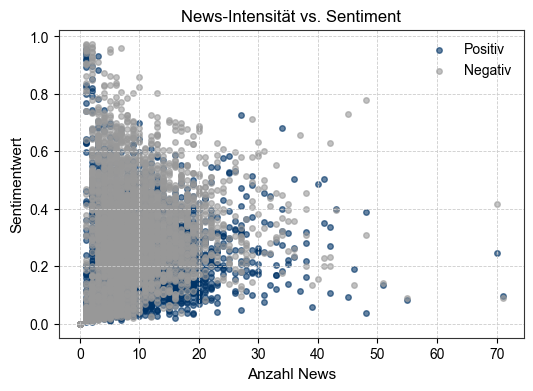

In [11]:
plt.figure(figsize=(6, 4))
plt.scatter(df["news_count"], df["pos_mean"], alpha=0.6, label="Positiv")
plt.scatter(df["news_count"], df["neg_mean"], alpha=0.6, label="Negativ")
plt.xlabel("Anzahl News")
plt.ylabel("Sentimentwert")
plt.title("News-Intensität vs. Sentiment")
plt.legend()
plt.show()


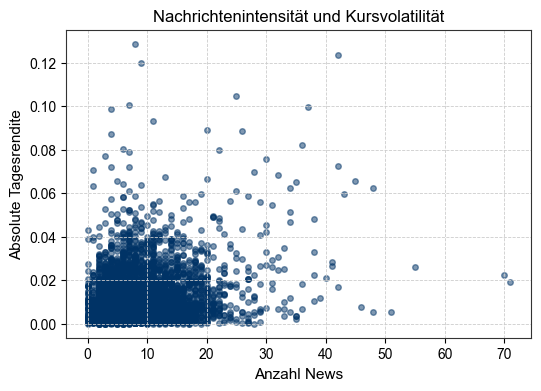

In [12]:
returns = df["Close"].pct_change().abs()

plt.figure(figsize=(6, 4))
plt.scatter(df["news_count"], returns, alpha=0.5)
plt.xlabel("Anzahl News")
plt.ylabel("Absolute Tagesrendite")
plt.title("Nachrichtenintensität und Kursvolatilität")
plt.show()


In [13]:
# 1) Gesamtanzahl Tage (Records) und Gesamtanzahl News-Artikel (über alle Tage aufsummiert)
n_days = len(df)
total_news = int(df["news_count"].sum())
mean_news_per_day = df["news_count"].mean()
days_with_zero_news = int((df["news_count"] == 0).sum())

print(f"Tage (Records):                {n_days}")
print(f"News gesamt (Summe news_count): {total_news}")
print(f"Ø News pro Tag:                {mean_news_per_day:.2f}")
print(f"Tage ohne News (news_count=0): {days_with_zero_news} ({days_with_zero_news/n_days*100:.2f}%)")

# 2) Dominantes Sentiment pro Tag (Kategorie mit höchster Wahrscheinlichkeit)
sent_cols = ["pos_mean", "neut_mean", "neg_mean"]
df["dominant_sentiment"] = df[sent_cols].idxmax(axis=1)

# Counts pro dominantes Sentiment (pro Tag)
dominant_counts = df["dominant_sentiment"].value_counts()

# Optional: saubere Labels
label_map = {"pos_mean": "positiv", "neut_mean": "neutral", "neg_mean": "negativ"}
dominant_counts_named = dominant_counts.rename(index=label_map)

print("\nDominantes Sentiment (pro Tag, max(pos/neut/neg)):")
for k in ["positiv", "neutral", "negativ"]:
    v = int(dominant_counts_named.get(k, 0))
    print(f"  {k:7s}: {v} Tage ({v/n_days*100:.2f}%)")

# 3) (Optional, oft hilfreich) Dominantes Sentiment gewichtet nach News-Anzahl
#    -> Approximation: Wie viele Artikel-Tage-Einheiten in Summe "überwiegend" pos/neut/neg waren
weighted = df.groupby("dominant_sentiment")["news_count"].sum().rename(index=label_map)
total_weighted = weighted.sum()

print("\nDominantes Sentiment (gewichtet nach news_count, Approximation):")
for k in ["positiv", "neutral", "negativ"]:
    v = float(weighted.get(k, 0.0))
    pct = (v / total_weighted * 100) if total_weighted > 0 else 0.0
    print(f"  {k:7s}: {int(v)} News ({pct:.2f}%)")

Tage (Records):                3905
News gesamt (Summe news_count): 35367
Ø News pro Tag:                9.06
Tage ohne News (news_count=0): 56 (1.43%)

Dominantes Sentiment (pro Tag, max(pos/neut/neg)):
  positiv: 432 Tage (11.06%)
  neutral: 2474 Tage (63.35%)
  negativ: 999 Tage (25.58%)

Dominantes Sentiment (gewichtet nach news_count, Approximation):
  positiv: 3476 News (9.83%)
  neutral: 22466 News (63.52%)
  negativ: 9425 News (26.65%)


In [14]:
from pathlib import Path

# === Pfad zu den Zeitreihen mit Sentiment ===
data_dir = Path("../../data/ts_with_sentiment")

# === Sammelstruktur ===
coverage_stats = []

for file in sorted(data_dir.glob("*_ts_with_sentiment.csv")):
    ticker = file.name.split("_")[0]

    df_tmp = pd.read_csv(file)

    total_news = df_tmp["news_count"].sum()
    mean_news = df_tmp["news_count"].mean()
    zero_days = (df_tmp["news_count"] == 0).sum()
    n_days = len(df_tmp)

    coverage_stats.append({
        "Ticker": ticker,
        "News gesamt": int(total_news),
        "Ø News pro Tag": round(mean_news, 2),
        "Tage ohne News (%)": round(zero_days / n_days * 100, 2)
    })

coverage_df = pd.DataFrame(coverage_stats).sort_values(
    "Ø News pro Tag", ascending=False
).reset_index(drop=True)

coverage_df


,Ticker,News gesamt,Ø News pro Tag,Tage ohne News (%)
0,AAPL,35367,9.06,1.43
1,MSFT,18143,4.65,11.75
2,DIS,8767,2.25,29.99
3,INTC,8257,2.12,29.41
4,JPM,7900,2.03,31.44
5,JNJ,5701,1.47,42.74
6,NKE,5057,1.31,48.63
7,IBM,4608,1.18,47.38
8,V,3550,0.90,55.05
9,KO,3208,0.82,57.11


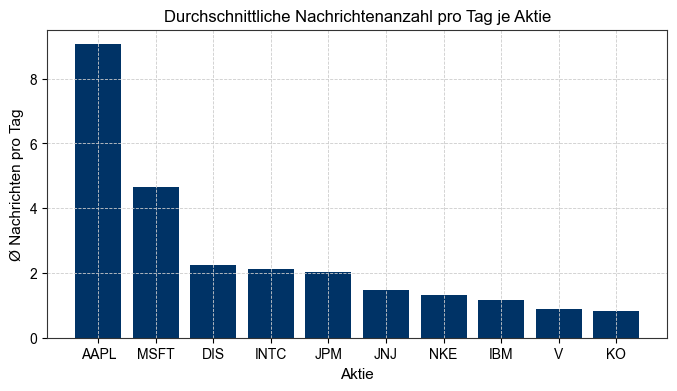

In [15]:
plt.figure(figsize=(8, 4))

plt.bar(
    coverage_df["Ticker"],
    coverage_df["Ø News pro Tag"]
)

plt.xlabel("Aktie")
plt.ylabel("Ø Nachrichten pro Tag")
plt.title("Durchschnittliche Nachrichtenanzahl pro Tag je Aktie")

plt.show()


In [16]:
# === Aggregierte Sentimentstruktur je Aktie ===

sentiment_stats = []

for file in sorted(data_dir.glob("*_ts_with_sentiment.csv")):
    ticker = file.name.split("_")[0]
    df_tmp = pd.read_csv(file)

    sent_cols = ["pos_mean", "neut_mean", "neg_mean"]
    dominant = df_tmp[sent_cols].idxmax(axis=1)

    counts = dominant.value_counts(normalize=True) * 100

    sentiment_stats.append({
        "Ticker": ticker,
        "Positiv (%)": round(counts.get("pos_mean", 0.0), 2),
        "Neutral (%)": round(counts.get("neut_mean", 0.0), 2),
        "Negativ (%)": round(counts.get("neg_mean", 0.0), 2),
    })

sentiment_df = pd.DataFrame(sentiment_stats).set_index("Ticker")
sentiment_df


,Positiv (%),Neutral (%),Negativ (%)
Ticker,,,
AAPL,11.06,63.35,25.58
DIS,42.59,38.40,19.02
IBM,61.19,24.74,14.07
INTC,46.61,28.30,25.09
JNJ,55.88,29.60,14.53
JPM,43.63,30.36,26.00
KO,68.08,20.01,11.92
MSFT,28.32,48.45,23.23
NKE,60.95,23.95,15.10


<Figure size 900x400 with 0 Axes>

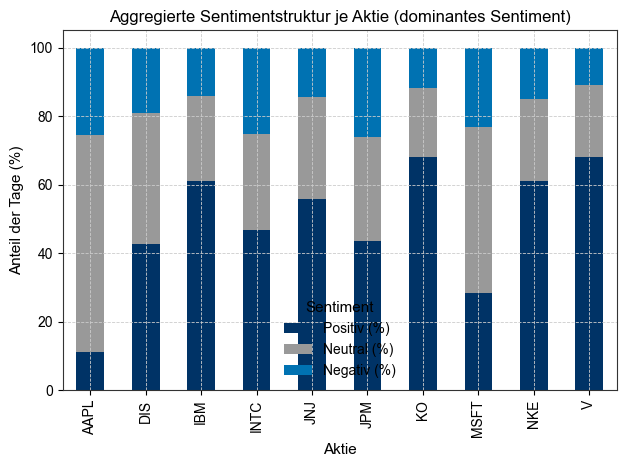

In [17]:
plt.figure(figsize=(9, 4))

sentiment_df[["Positiv (%)", "Neutral (%)", "Negativ (%)"]].plot(
    kind="bar",
    stacked=True
)

plt.xlabel("Aktie")
plt.ylabel("Anteil der Tage (%)")
plt.title("Aggregierte Sentimentstruktur je Aktie (dominantes Sentiment)")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


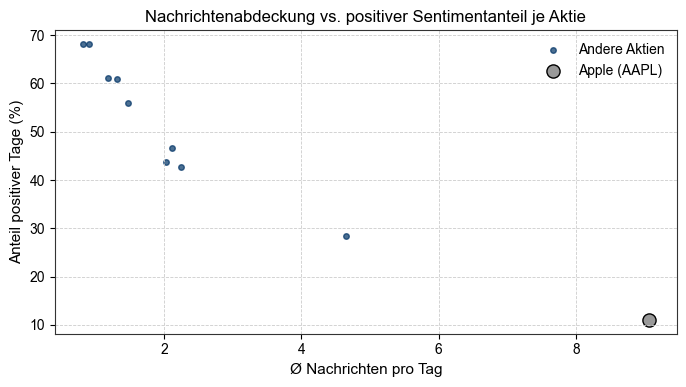

In [18]:
# -------------------------------------------------
# Zusammenhang: Nachrichtenabdeckung vs. positives Sentiment
# -------------------------------------------------

# Merge: News-Abdeckung + Sentimentstruktur
df_scatter = coverage_df.merge(
    sentiment_df.reset_index(),
    on="Ticker",
    how="inner"
)

plt.figure(figsize=(7, 4))

# Alle Aktien (grau)
others = df_scatter[df_scatter["Ticker"] != "AAPL"]
plt.scatter(
    others["Ø News pro Tag"],
    others["Positiv (%)"],
    alpha=0.7,
    label="Andere Aktien"
)

# Apple hervorheben
apple = df_scatter[df_scatter["Ticker"] == "AAPL"]
plt.scatter(
    apple["Ø News pro Tag"],
    apple["Positiv (%)"],
    s=90,
    marker="o",
    edgecolor="black",
    label="Apple (AAPL)"
)

plt.xlabel("Ø Nachrichten pro Tag")
plt.ylabel("Anteil positiver Tage (%)")
plt.title("Nachrichtenabdeckung vs. positiver Sentimentanteil je Aktie")
plt.legend()
plt.tight_layout()
plt.show()
